# Goal

We're going to implement variables in Model and Feature Map drawing so we won't need to calculate Convolution layer outputs and FM channels manually.

We're going to change params of the model and see if our softcoded model handles changes automatically.

* 1st conv - 3 channels
* 2nd conv - 6 channels
* Assymmetric kernel size (3,2)
* Assymmetric stride size (2,3)
* Softcoded inputs to fc1

# Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Gaussian Blurs

In [2]:
n_per_clust = 1000
img_size = 91
x = np.linspace(-4,4,img_size)
X, Y = np.meshgrid(x, x)

# two widths
widths = [1.8, 2.4]

# images and labels placeholders
images = torch.zeros(2*n_per_clust, 1, img_size, img_size)
labels = torch.zeros(2*n_per_clust)

for i in range(2*1000):
  ro = np.random.randn(2) # random offset
  G = np.exp(
      - ((X-ro[0])**2 + (Y-ro[1])**2) /
        (2*widths[i%2]**2) # every other label is odd or even due to i%2
  )

  # add noise
  G = G + np.random.randn(img_size, img_size) / 5

  # add image and label
  images[i,:,:,:] = torch.tensor(G).view(1,img_size, img_size)
  labels[i] = i%2

labels = labels[:,None]

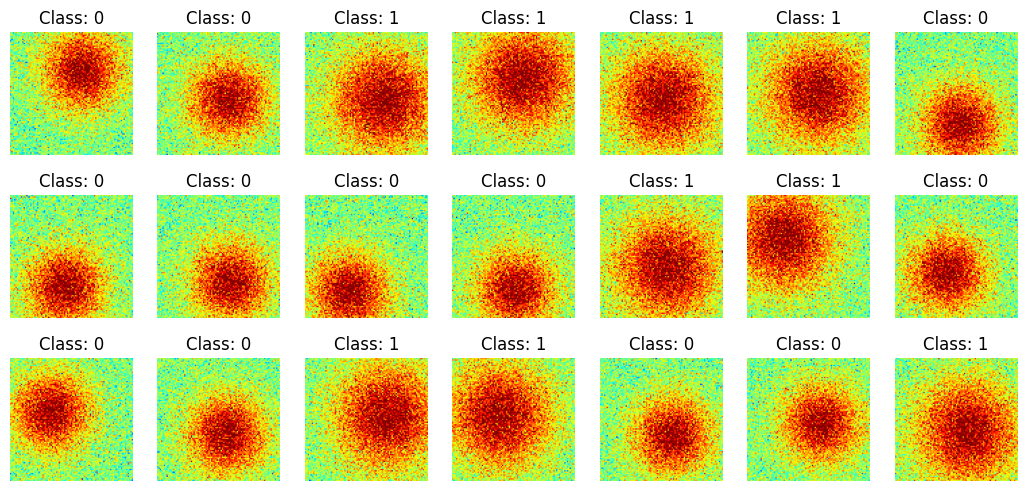

In [3]:
fig, axs = plt.subplots(3, 7, figsize = (13, 6))

for i, ax in enumerate(axs.flatten()):
  rand_row = np.random.randint(images.shape[0])
  ax.imshow(images[rand_row].squeeze(), vmin = -1, vmax = 1, cmap = 'jet')
  ax.set_title(f'Class: {labels[rand_row].item():.0f}')
  ax.axis('off')
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Train/Test DataLoader

In [4]:
train_data, test_data, train_labels, test_labels = train_test_split(images, labels, test_size = .8)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = test_data.shape[0], shuffle = False)

# Model

In [5]:
def CreateModel(kernel = (3,2),
                stride = (2,3),
                img = (91,91),
                padding = (1,1),
                conv_1_out = 3,
                conv_2_out = 6,
                pool = (2,2),
                fc_1_out = 50,
                fc_2_out = 1):

  class CreateNet(nn.Module):
    def __init__(self):
      super().__init__()

      # Activations
      self.relu = nn.ReLU()
      self.max_pool = nn.MaxPool2d(pool)

      # Conv
      self.conv_1 = nn.Conv2d(1,conv_1_out,kernel,stride,padding)
      self.conv_1_out_width = ((img[1] + 2 * padding[1] - kernel[1]) // stride[1] ) + 1
      self.conv_1_out_height = ((img[0] + 2 * padding[0] - kernel[0]) // stride[0] ) + 1
      self.conv_1_out_width  //= pool[1]
      self.conv_1_out_height //= pool[0]

      self.conv_2 = nn.Conv2d(conv_1_out,conv_2_out,kernel,stride,padding)
      self.conv_2_out_width = ((self.conv_1_out_width + 2 * padding[1] - kernel[1]) // stride[1] ) + 1
      self.conv_2_out_height = ((self.conv_1_out_height + 2 * padding[0] - kernel[0]) // stride[0] ) + 1
      self.conv_2_out_width  //= pool[1]
      self.conv_2_out_height //= pool[0]

      # FCs
      self.fc1 = nn.Linear(self.conv_2_out_width * self.conv_2_out_height * conv_2_out, fc_1_out)
      self.fc2 = nn.Linear(fc_1_out, fc_2_out)

    def forward(self, x):
      conv_1 = self.relu(self.conv_1(x))
      x = self.max_pool(conv_1)

      conv_2 = self.relu(self.conv_2(x))
      x = self.max_pool(conv_2)

      x = torch.flatten(x, 1)
      x = self.relu(self.fc1(x))
      x = self.fc2(x)
      return x, conv_1, conv_2

  net = CreateNet()
  loss_fn = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 1e-3)

  return net, loss_fn, optimizer

## Test on different params

In [6]:
net, loss_fn, optimizer = CreateModel(
    img = (41,41),
    pool = (3,2),
    fc_1_out = 35,
)
summary(net, (1, 41, 41))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 3, 21, 14]              21
              ReLU-2            [-1, 3, 21, 14]               0
         MaxPool2d-3              [-1, 3, 7, 7]               0
            Conv2d-4              [-1, 6, 4, 3]             114
              ReLU-5              [-1, 6, 4, 3]               0
         MaxPool2d-6              [-1, 6, 1, 1]               0
            Linear-7                   [-1, 35]             245
              ReLU-8                   [-1, 35]               0
            Linear-9                    [-1, 1]              36
Total params: 416
Trainable params: 416
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.02
Params size (MB): 0.00
Estimated Total Size (MB): 0.02
---------------------------------------------------

In [7]:
net, loss_fn, optimizer = CreateModel(
    kernel = (4,5),
    stride = (1,3),
    img = (31,21),
    padding = (3,3),
    conv_1_out = 4,
    conv_2_out = 10,
    pool = (4,2),
    fc_1_out = 60,
    fc_2_out = 10
)
summary(net, (1, 31, 21))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1             [-1, 4, 34, 8]              84
              ReLU-2             [-1, 4, 34, 8]               0
         MaxPool2d-3              [-1, 4, 8, 4]               0
            Conv2d-4            [-1, 10, 11, 2]             810
              ReLU-5            [-1, 10, 11, 2]               0
         MaxPool2d-6             [-1, 10, 2, 1]               0
            Linear-7                   [-1, 60]           1,260
              ReLU-8                   [-1, 60]               0
            Linear-9                   [-1, 10]             610
Total params: 2,764
Trainable params: 2,764
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.01
Estimated Total Size (MB): 0.04
-----------------------------------------------

## Real Data Test

In [8]:
net, loss_fn, optimizer = CreateModel()
X, y = next(iter(train_dataloader))
y_hat, feature_map_1, feature_map_2 = net(X)
loss = loss_fn(y_hat, y)
loss

tensor(0.6871, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [9]:
summary(net, (1, img_size, img_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 3, 46, 31]              21
              ReLU-2            [-1, 3, 46, 31]               0
         MaxPool2d-3            [-1, 3, 23, 15]               0
            Conv2d-4             [-1, 6, 12, 6]             114
              ReLU-5             [-1, 6, 12, 6]               0
         MaxPool2d-6              [-1, 6, 6, 3]               0
            Linear-7                   [-1, 50]           5,450
              ReLU-8                   [-1, 50]               0
            Linear-9                    [-1, 1]              51
Total params: 5,636
Trainable params: 5,636
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 0.08
Params size (MB): 0.02
Estimated Total Size (MB): 0.13
-----------------------------------------------

# Train

In [10]:
def RunModel():
  # number of epochs
  epochs = 20

  # create a new model
  net, loss_fn, optimizer = CreateModel()

  # initialize losses
  train_losses = torch.zeros(epochs)
  test_losses = torch.zeros(epochs)
  train_accs = torch.zeros(epochs)
  test_accs = torch.zeros(epochs)

  for epoch in range(epochs):
    # loop over training data batches
    batch_losses = []
    batch_accs = []

    for X, y in train_dataloader:

      # forward pass and loss
      y_hat = net(X)[0]
      loss = loss_fn(y_hat, y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc = ((y_hat > 0).float() == y).float().mean().item()

      # batch loss and acc
      batch_losses.append(loss.item())
      batch_accs.append(batch_acc)

    # losses
    train_losses[epoch] = np.mean(batch_losses)
    train_accs[epoch] = 100 * np.mean(batch_accs)

    # test acc
    X, y = next(iter(test_dataloader))
    with torch.no_grad():
      y_hat = net(X)[0]
      loss = loss_fn(y_hat, y)

    test_losses[epoch] = loss.item()
    test_acc = 100 * ((y_hat > 0).float() == y).float().mean().item()
    test_accs[epoch] = test_acc

    print(f'Epoch {epoch} Train Loss: {train_losses[epoch]:.4f}, Test Loss: {test_losses[epoch]:.4f}, Train Acc: {train_accs[epoch]:.4f}, Test Acc: {test_accs[epoch]:.4f}')

  return train_losses, test_losses, train_accs, test_accs, net

In [11]:
train_losses, test_losses, train_accs, test_accs, net = RunModel()

Epoch 0 Train Loss: 0.6937, Test Loss: 0.6928, Train Acc: 49.2788, Test Acc: 50.1875
Epoch 1 Train Loss: 0.6928, Test Loss: 0.6922, Train Acc: 49.5192, Test Acc: 50.1875
Epoch 2 Train Loss: 0.6920, Test Loss: 0.6912, Train Acc: 60.3365, Test Acc: 54.7500
Epoch 3 Train Loss: 0.6905, Test Loss: 0.6887, Train Acc: 50.0000, Test Acc: 50.3125
Epoch 4 Train Loss: 0.6865, Test Loss: 0.6834, Train Acc: 66.8269, Test Acc: 76.0625
Epoch 5 Train Loss: 0.6792, Test Loss: 0.6705, Train Acc: 90.3846, Test Acc: 86.2500
Epoch 6 Train Loss: 0.6568, Test Loss: 0.6332, Train Acc: 85.3365, Test Acc: 95.3750
Epoch 7 Train Loss: 0.5985, Test Loss: 0.5380, Train Acc: 92.7885, Test Acc: 96.1250
Epoch 8 Train Loss: 0.4735, Test Loss: 0.3716, Train Acc: 94.4712, Test Acc: 98.0000
Epoch 9 Train Loss: 0.2861, Test Loss: 0.1975, Train Acc: 97.8365, Test Acc: 97.3750
Epoch 10 Train Loss: 0.1425, Test Loss: 0.1064, Train Acc: 99.2788, Test Acc: 97.6250
Epoch 11 Train Loss: 0.0799, Test Loss: 0.0651, Train Acc: 98.31

# Loss/Acc

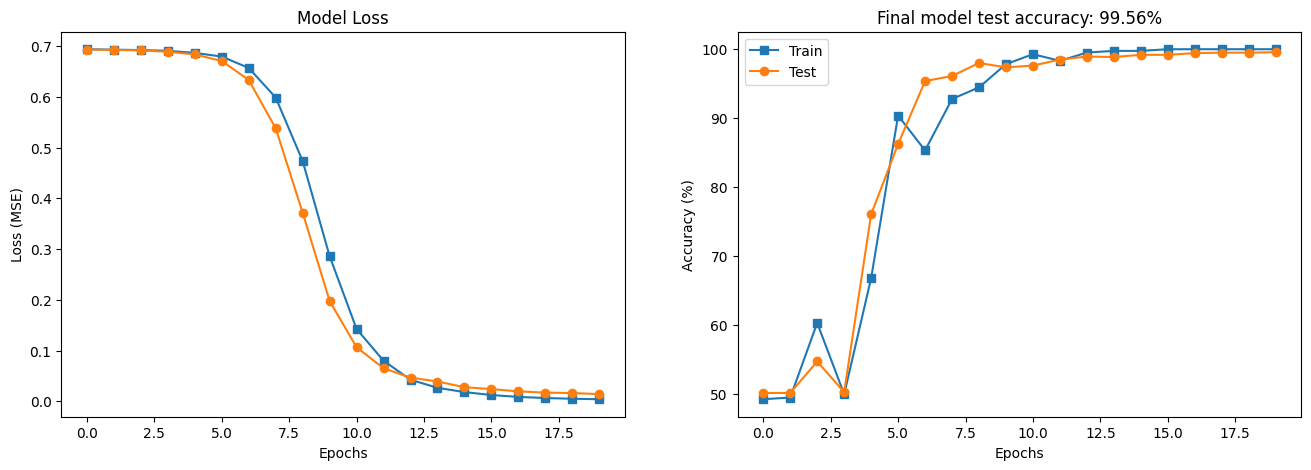

In [12]:
fig, ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(train_losses, 's-', label = 'Train')
ax[0].plot(test_losses, 'o-', label = 'Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (MSE)')
ax[0].set_title('Model Loss')

ax[1].plot(train_accs, 's-', label = 'Train')
ax[1].plot(test_accs, 'o-', label = 'Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {test_accs[-1]:.2f}%')
ax[1].legend()

plt.show()

## Draw Feature Maps

In [13]:
def drawFeatureMaps(feature_map):
  fm_channels = feature_map.shape[1]

  fig, axs = plt.subplots(fm_channels + 1, 10, figsize = (18, fm_channels * 3))

  for pic in range(10):
    axs[0][pic].imshow(X[pic,:,:,:].squeeze(), cmap = 'jet', vmin = 0, vmax = 1)
    axs[0][pic].set_title(f'Image: {pic}')
    axs[0][pic].axis('off')

    for fm in range(fm_channels):
      img = feature_map[pic,fm,:,:].detach().squeeze()
      axs[fm+1][pic].imshow(img,
                            cmap = 'inferno',
                            vmin = 0,
                            vmax = torch.max(img)*.9,
                            )
      axs[fm+1][pic].axis('off')
      # axs[fm+1][pic].text(-5, 45, f'FM {fm}', ha = 'right')

  plt.tight_layout()
  plt.suptitle('Feature Map Activations for 10 Images',
              x = .5,
              y = 1.01,
              fontweight = 'bold',
              fontsize = 14)
  plt.show()

### feature_map_1

In [14]:
feature_map_1.shape

torch.Size([32, 3, 46, 31])

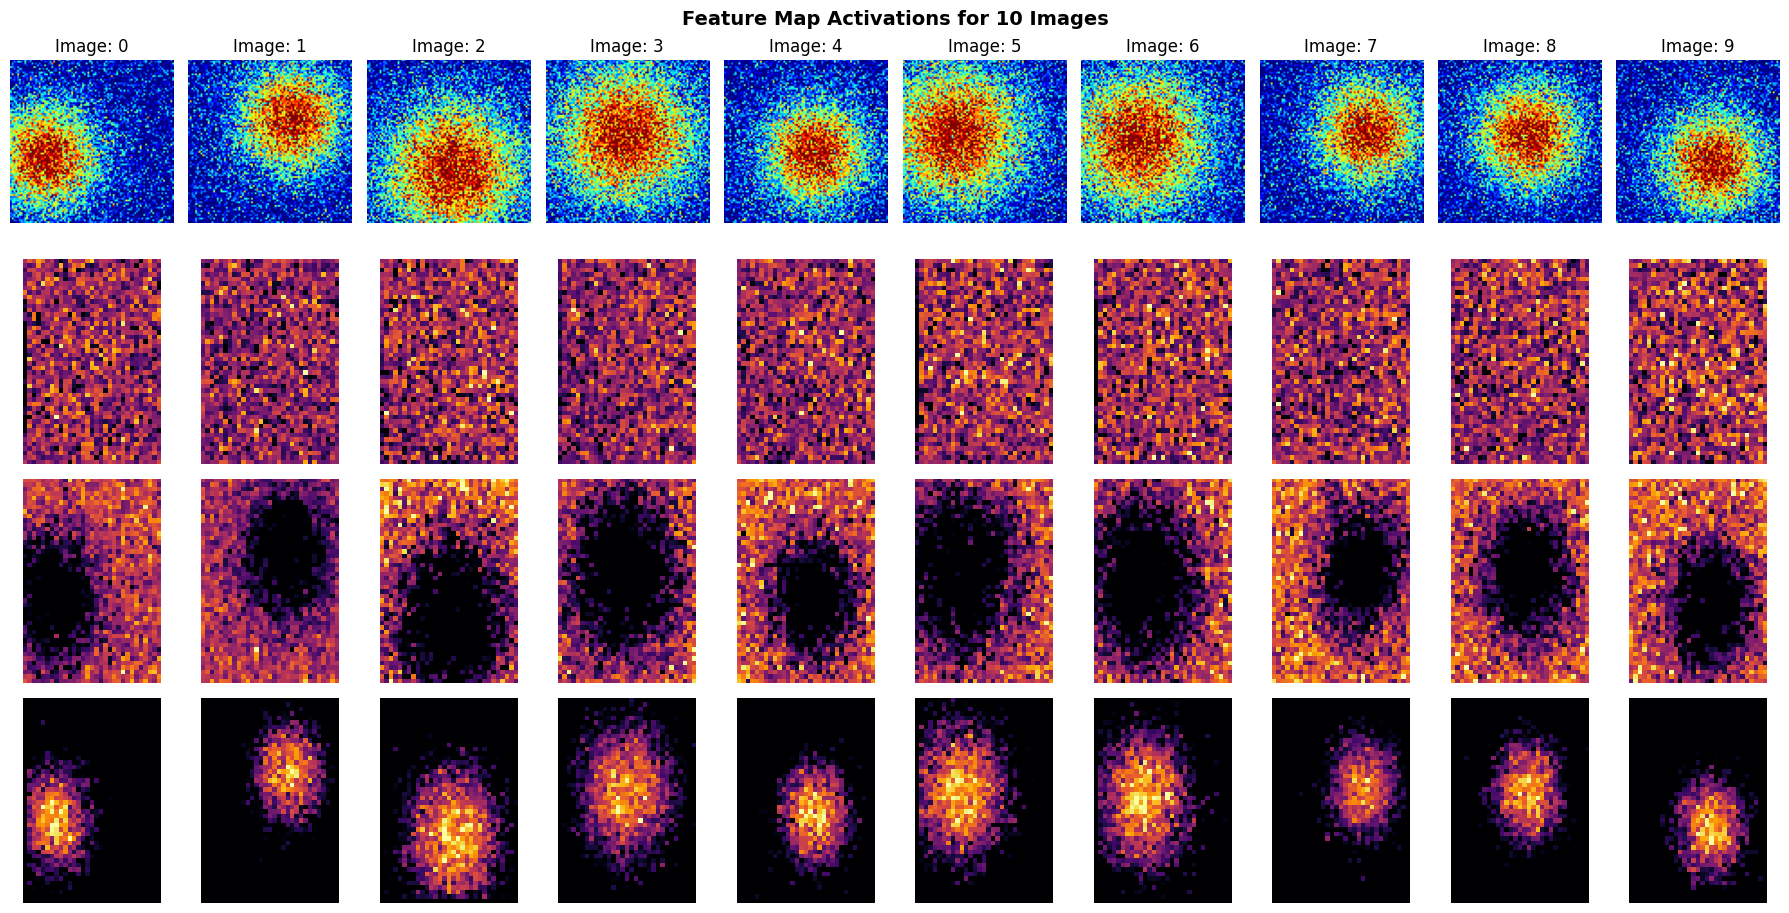

In [15]:
drawFeatureMaps(feature_map_1)

## feature_map_2

In [16]:
feature_map_2.shape

torch.Size([32, 6, 12, 6])

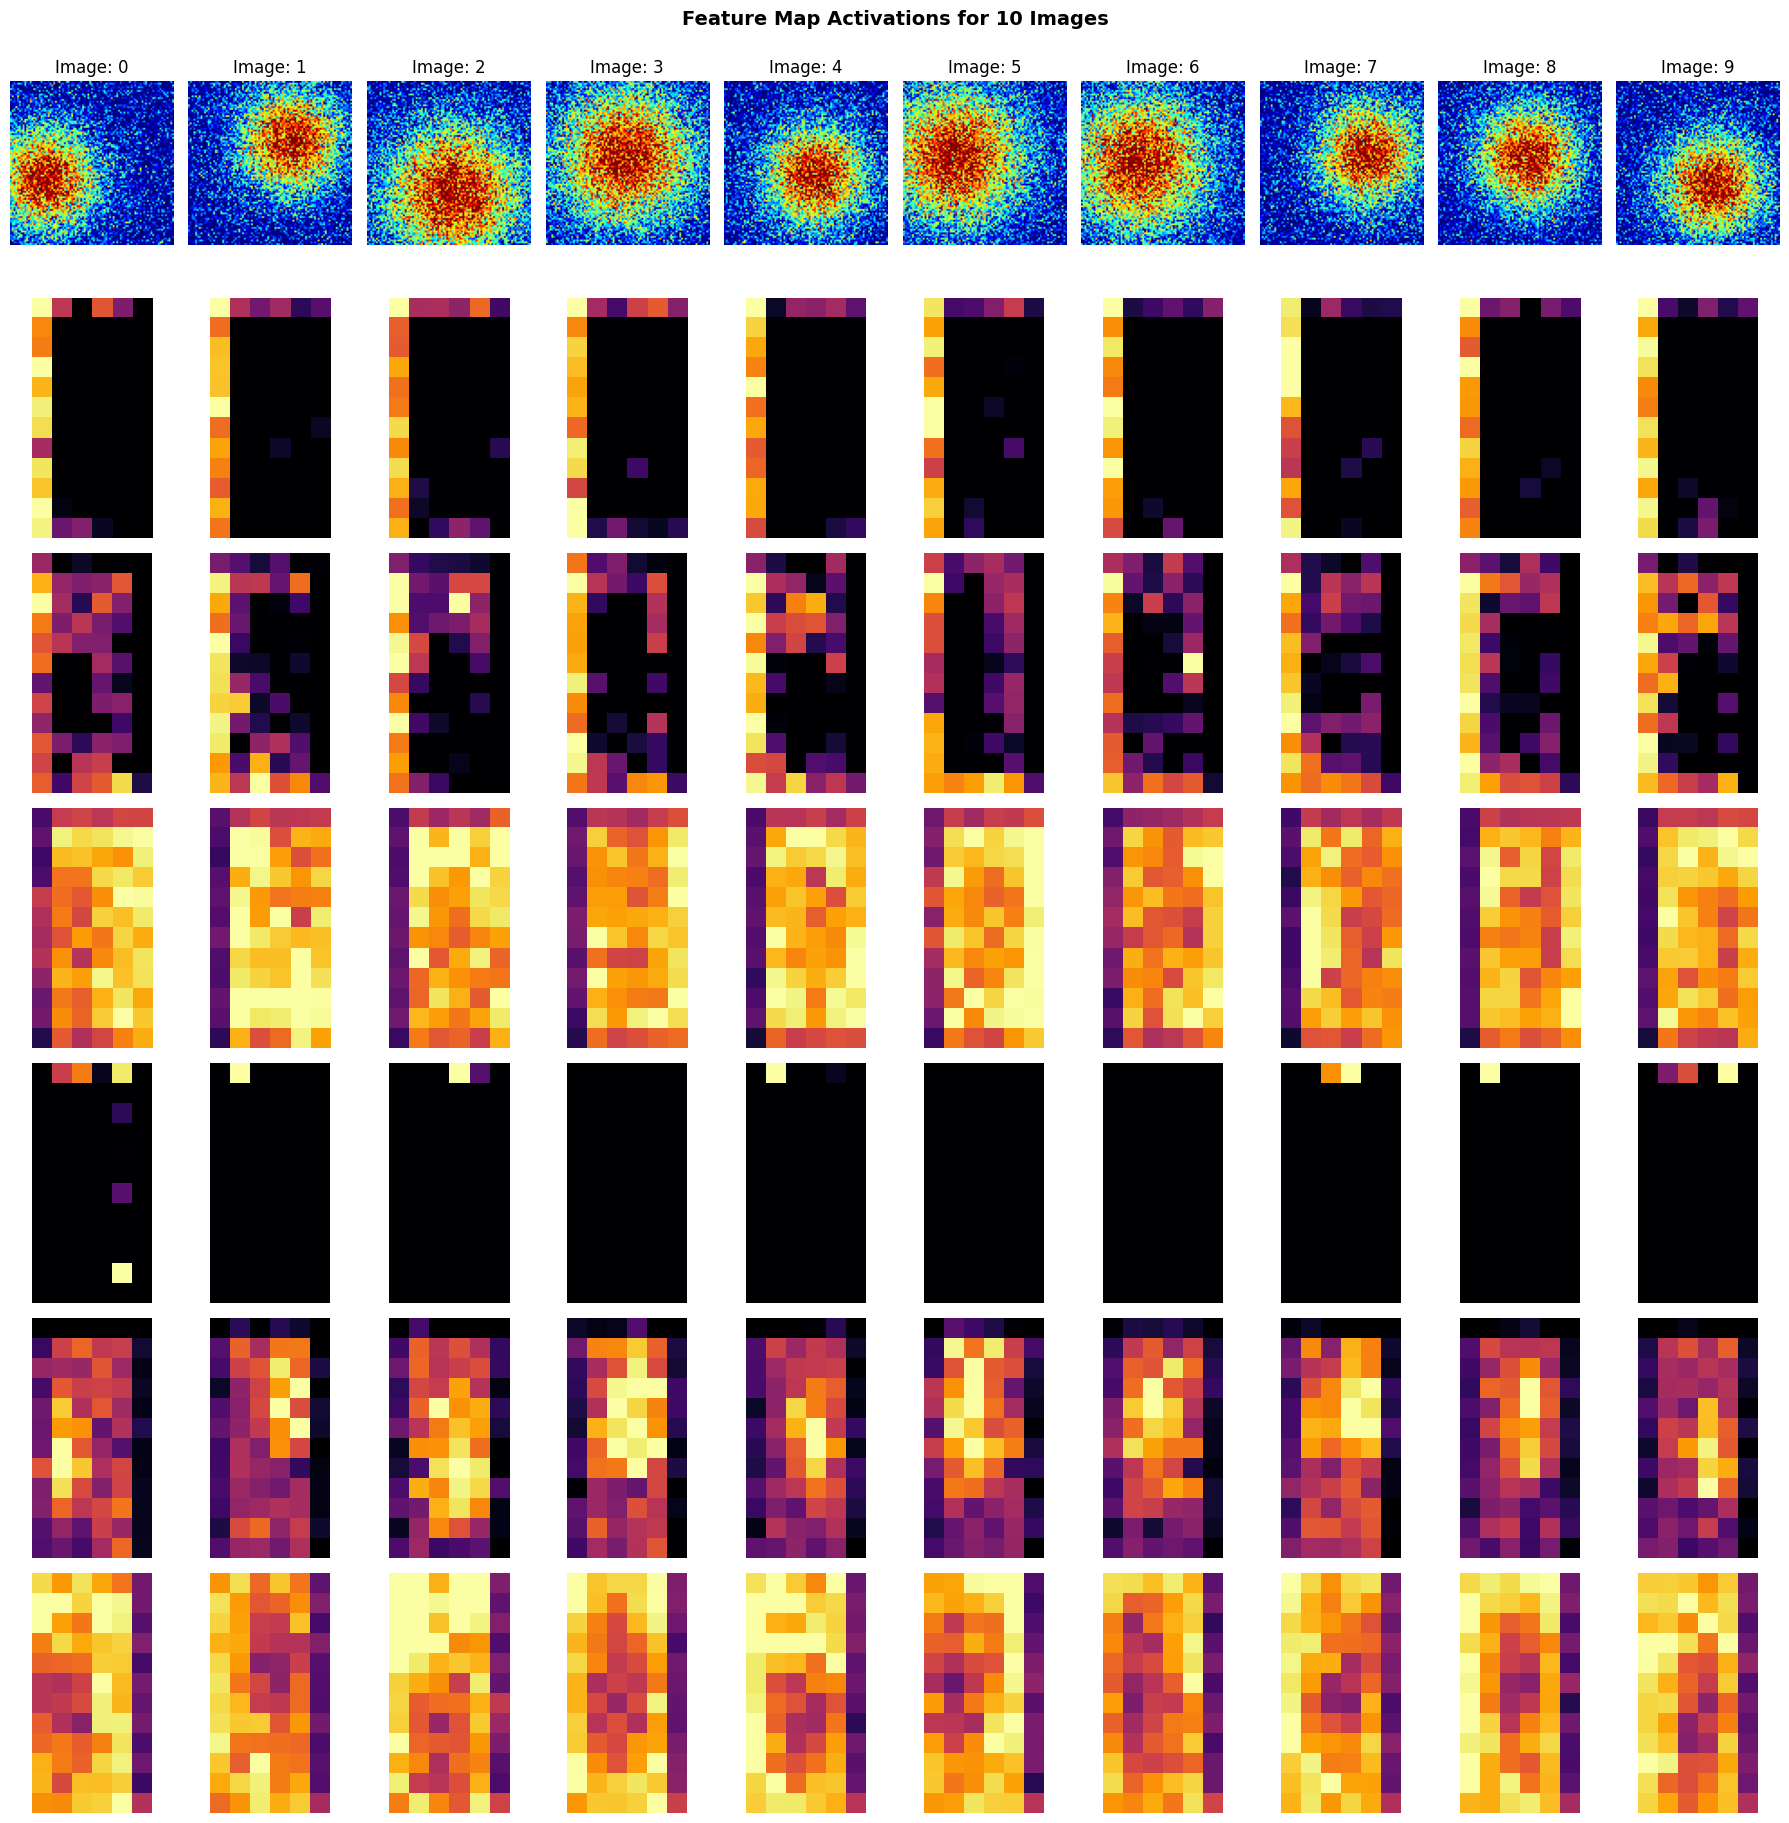

In [17]:
drawFeatureMaps(feature_map_2)